# Simulaciones con medias estocásticas de varias simulaciones

In [135]:
### PARÁMETROS PARA HACER LOS PLOTS, CAMBIAR CADA VEZ #########

simulaciones = 50   #Número total de simulaciones
T_Total = 1000      #Número total de pasos
media = 10          #Cada cuantos pasos hace media
memoria = 2        #Memoria del demonio
num_sigmas = 3      #Cuantas sigmas quieres para el error.


In [136]:
### LIBRERÍAS NECESARIAS ##############

import os
import numpy as np
import matplotlib.pyplot as plt

In [137]:
### FUNCIONES PARA TOdO #############

#Pongo la caperta de plots
carpeta_plots = "plots"
os.makedirs(carpeta_plots, exist_ok=True)


def leer_txt(nombre_archivo):
    """
    Lee un archivo .txt situado en la misma carpeta que el notebook.

    Sirve tanto para archivos con una columna como con dos columnas.
    Devuelve siempre un array 2D:
        - shape = (N, 1) si hay una columna
        - shape = (N, 2) si hay dos columnas
    """
    datos = np.loadtxt(nombre_archivo)

    if datos.ndim == 1:
        datos = datos.reshape(-1, 1)

    return datos


def media_por_bloques(datos, media):
    """
    Agrupa los datos en bloques de tamaño 'media' y calcula la media de cada bloque.

    Ejemplo:
        media = 5

        filas 0,1,2,3,4       -> primer punto ploteado
        filas 5,6,7,8,9       -> segundo punto ploteado
        filas 10,11,12,13,14  -> tercer punto ploteado

    Si al final sobran filas y no completan un bloque entero, se descartan.
    """
    if media <= 0:
        raise ValueError("La variable 'media' debe ser mayor que cero.")

    num_filas = datos.shape[0]
    num_bloques = num_filas // media

    if num_bloques == 0:
        raise ValueError(
            f"El archivo tiene {num_filas} filas, pero media = {media}. "
            "No hay suficientes datos para hacer ni un bloque."
        )

    # Recorto para quedarme solo con bloques completos
    datos_recortados = datos[:num_bloques * media]

    # Forma:
    # (num_bloques, media, num_columnas)
    datos_bloques = datos_recortados.reshape(num_bloques, media, datos.shape[1])

    # Media dentro de cada bloque temporal
    datos_promediados = datos_bloques.mean(axis=1)

    return datos_promediados


def eje_temporal_promediado(num_bloques, media):
    """
    Eje temporal asociado a los bloques promediados.

    Para media = 5:
        primer punto representa los pasos 0-4
        segundo punto representa los pasos 5-9
        etc.

    Uso el centro del bloque:
        2, 7, 12, ...
    """
    return (np.arange(num_bloques) * media) + (media - 1) / 2


def plot_evolucion(nombre_archivo, titulo, ylabel, nombre_guardado, etiquetas=None):
    """
    Lee un txt, promedia cada 'media' pasos temporales,
    representa todas sus columnas frente al tiempo
    y guarda la figura en la carpeta plots.
    """
    datos = leer_txt(nombre_archivo)

    # Aquí está la parte importante:
    # no se plotea cada fila directamente, sino la media de cada bloque de 'media' filas.
    datos_promediados = media_por_bloques(datos, media)

    t = eje_temporal_promediado(len(datos_promediados), media)

    plt.figure(figsize=(8, 5))

    for col in range(datos_promediados.shape[1]):
        if etiquetas is not None and col < len(etiquetas):
            label = etiquetas[col]
        else:
            label = f"Columna {col + 1}"

        plt.plot(t, datos_promediados[:, col], label=label, linewidth=2)

    plt.xlabel("Tiempo")
    plt.ylabel(ylabel)
    plt.title(f"{titulo} media cada {media} pasos en {simulaciones} simulaciones, M={memoria}")
    plt.grid(True, alpha=0.3)

    if datos_promediados.shape[1] > 1:
        plt.legend()

    plt.tight_layout()

    ruta_guardado = os.path.join(carpeta_plots, nombre_guardado)
    plt.savefig(ruta_guardado, dpi=1000)
    plt.show()

    print(f"Plot guardado en: {ruta_guardado}")

## Simulaciones con errores

In [138]:
### FUNCIONES NECESARIAS #################


def leer_txt(nombre_archivo):
    '''
    Lee un archivo .txt situado en la misma carpeta que el notebook.

    Devuelve siempre un array 2D:
        - shape = (N, 1) si hay una columna
        - shape = (N, M) si hay varias columnas
    '''
    datos = np.loadtxt(nombre_archivo)

    if datos.ndim == 1:
        datos = datos.reshape(-1, 1)

    return datos


def media_temporal_por_bloques(datos, media):
    '''
    Agrupa cada "media" pasos temporales y calcula la media de cada bloque.

    Ejemplo:
        media = 10

        filas 0-9    -> primer punto
        filas 10-19  -> segundo punto
        filas 20-29  -> tercer punto

    Si sobran filas al final, se descartan.
    '''
    if media <= 0:
        raise ValueError("La variable 'media' debe ser mayor que cero.")

    if datos.ndim == 1:
        datos = datos.reshape(-1, 1)

    num_filas = datos.shape[0]
    num_bloques = num_filas // media

    if num_bloques == 0:
        raise ValueError(
            f"El archivo tiene {num_filas} filas, pero media = {media}. "
            "No hay datos suficientes para formar ni un bloque."
        )

    datos_recortados = datos[:num_bloques * media]
    datos_bloques = datos_recortados.reshape(num_bloques, media, datos.shape[1])

    return datos_bloques.mean(axis=1)


def sigma_temporal_por_bloques(sigmas, media):
    '''
    Agrupa cada "media" pasos temporales y propaga las sigmas para la media del bloque.

    Si en un bloque tienes valores:
        x_1, x_2, ..., x_m

    y cada uno tiene incertidumbre sigma_i, entonces para la media temporal:

        x_bloque = (x_1 + ... + x_m)/m

    la sigma propagada es:

        sigma_bloque = sqrt(sigma_1^2 + ... + sigma_m^2)/m

    Esto asume que los errores de pasos distintos son independientes.
    '''
    if media <= 0:
        raise ValueError("La variable 'media' debe ser mayor que cero.")

    if sigmas.ndim == 1:
        sigmas = sigmas.reshape(-1, 1)

    num_filas = sigmas.shape[0]
    num_bloques = num_filas // media

    if num_bloques == 0:
        raise ValueError(
            f"El archivo tiene {num_filas} filas, pero media = {media}. "
            "No hay datos suficientes para formar ni un bloque."
        )

    sigmas_recortadas = sigmas[:num_bloques * media]
    sigmas_bloques = sigmas_recortadas.reshape(num_bloques, media, sigmas.shape[1])

    return np.sqrt(np.sum(sigmas_bloques**2, axis=1)) / media


def plot_evolucion_con_sigma_y_media_bloques(nombre_archivo_media, nombre_archivo_sigma,
                                             titulo, ylabel, nombre_guardado,
                                             etiquetas=None):
    '''
    Lee:
        - Ave_...
        - Sigma_...

    Luego:
        1. Agrupa cada "media" pasos temporales.
        2. Calcula la media temporal de cada bloque.
        3. Propaga la sigma de cada bloque.
        4. Plotea:
            - curva media
            - curva + num_sigmas*sigma
            - curva - num_sigmas*sigma
    '''

    datos_media = leer_txt(nombre_archivo_media)
    datos_sigma = leer_txt(nombre_archivo_sigma)

    if datos_media.shape != datos_sigma.shape:
        raise ValueError(
            f"Las dimensiones no coinciden entre {nombre_archivo_media} y {nombre_archivo_sigma}: "
            f"{datos_media.shape} vs {datos_sigma.shape}"
        )

    datos_media_bloques = media_temporal_por_bloques(datos_media, media)
    datos_sigma_bloques = sigma_temporal_por_bloques(datos_sigma, media)

    # Aquí se controla si quieres 1 sigma, 2 sigmas, 3 sigmas, etc.
    datos_error_bloques = num_sigmas * datos_sigma_bloques

    # Centro temporal de cada bloque:
    # media=10 -> primer punto en t=4.5, segundo en t=14.5, etc.
    t = np.arange(datos_media_bloques.shape[0]) * media + (media - 1) / 2

    plt.figure(figsize=(8, 5))

    for col in range(datos_media_bloques.shape[1]):
        y = datos_media_bloques[:, col]
        error = datos_error_bloques[:, col]

        if etiquetas is not None and col < len(etiquetas):
            label = etiquetas[col]
        else:
            label = f"Curva {col + 1}"

        linea_central, = plt.plot(t, y, linewidth=2, label=label)
        color = linea_central.get_color()

        plt.plot(
            t,
            y + error,
            color=color,
            alpha=0.35,
            linewidth=1.5,
            linestyle="-",
            label=f"{label} + {num_sigmas}$\sigma$"
        )

        plt.plot(
            t,
            y - error,
            color=color,
            alpha=0.35,
            linewidth=1.5,
            linestyle="-",
            label=f"{label} - {num_sigmas}$\sigma$"
        )

    plt.xlabel("Temporal step t")
    plt.ylabel(ylabel)
    plt.title(titulo + f" — {simulaciones} simulations, average {media} steps, ±{num_sigmas}$\sigma$")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    ruta_guardado = os.path.join(carpeta_plots, nombre_guardado)
    plt.savefig(ruta_guardado, dpi=300)
    plt.show()

    print(f"Plot guardado en: {ruta_guardado}")

<>:150: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:160: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:165: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:150: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:160: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:165: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\diego\AppData\Local\Temp\ipykernel_16608\4027044587.py:150: S

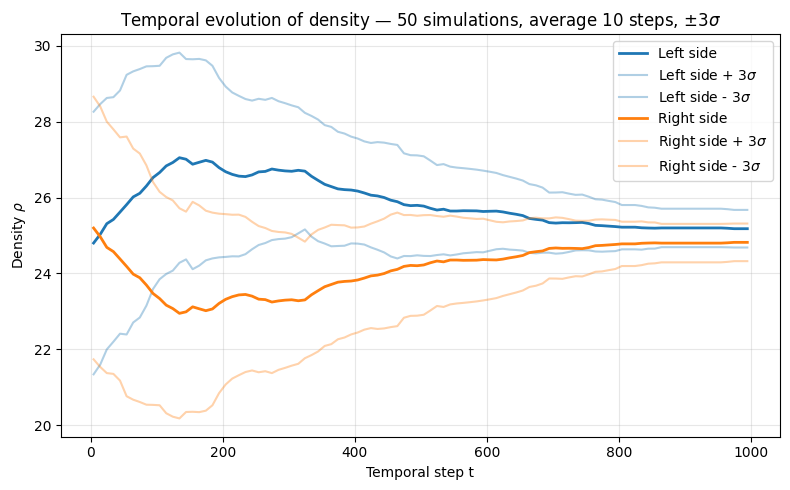

Plot guardado en: plots\evolucion_densidad_con_3_sigma_media_temporal.png


In [139]:
### DENSIDAD CON ERRORES #######
plot_evolucion_con_sigma_y_media_bloques(
    nombre_archivo_media="Ave_Density.txt",
    nombre_archivo_sigma="Sigma_Densidad.txt",
    titulo="Temporal evolution of density",
    ylabel=r"Density $\rho$",
    nombre_guardado=f"evolucion_densidad_con_{num_sigmas}_sigma_media_temporal.png",
    etiquetas=["Left side", "Right side"]
)


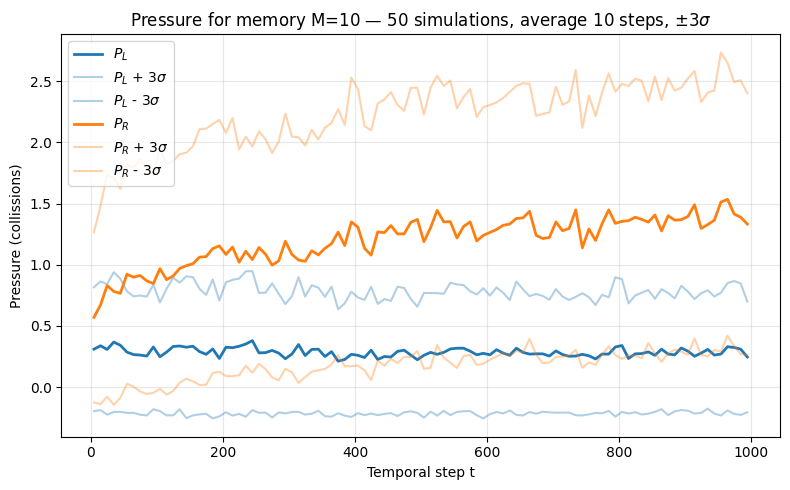

Plot guardado en: plots\evolucion_presion_con_3_sigma_media_temporal.png


In [140]:
### PRESIÓN CON ERRORES ###########

Nh = 25
Nc = 25

Ph = 0.9
Pc = 0.5

M = 10

titulopart =fr"Pressure for $N_h$={Nh}, $N_c$={Nc}"
titulomov = fr"Pressure for $P_h$ = {Ph}, $P_h$={Pc}"
titulomem = fr"Pressure for memory M={M}"

plot_evolucion_con_sigma_y_media_bloques(
    nombre_archivo_media="Ave_Presion.txt",
    nombre_archivo_sigma="Sigma_Presion.txt",
    titulo=titulomem,
    ylabel="Pressure (collissions)",
    nombre_guardado=f"evolucion_presion_con_{num_sigmas}_sigma_media_temporal.png",
    etiquetas=[r"$P_L$", r"$P_R$"]
)

In [152]:
memoria = 100        #Memoria del demonio

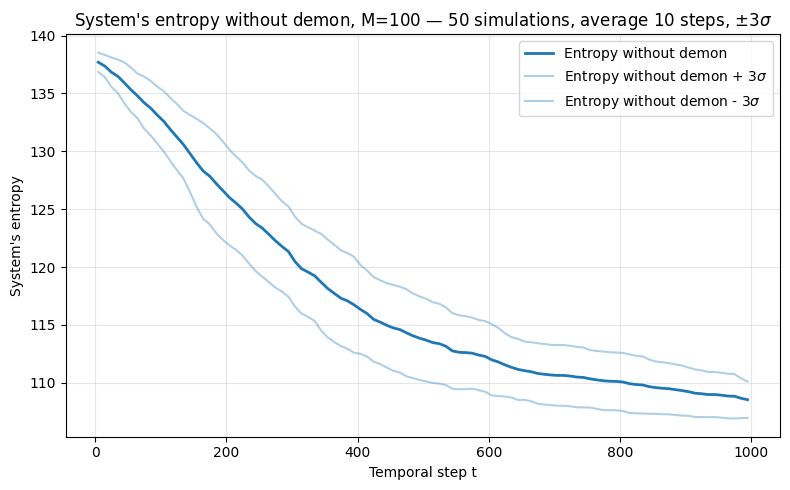

Plot guardado en: plots\evolucion_entropia_sin_demonio_con_3_sigma_media_temporal.png


In [153]:
### ENTROPÍA DEL SISTEMA CON ERRORES ###############
plot_evolucion_con_sigma_y_media_bloques(
    nombre_archivo_media="Ave_Entropy.txt",
    nombre_archivo_sigma="Sigma_Entropia.txt",
    titulo=f"System's entropy without demon, M={memoria}",
    ylabel="System's entropy",
    nombre_guardado=f"evolucion_entropia_sin_demonio_con_{num_sigmas}_sigma_media_temporal.png",
    etiquetas=["Entropy without demon"]
)

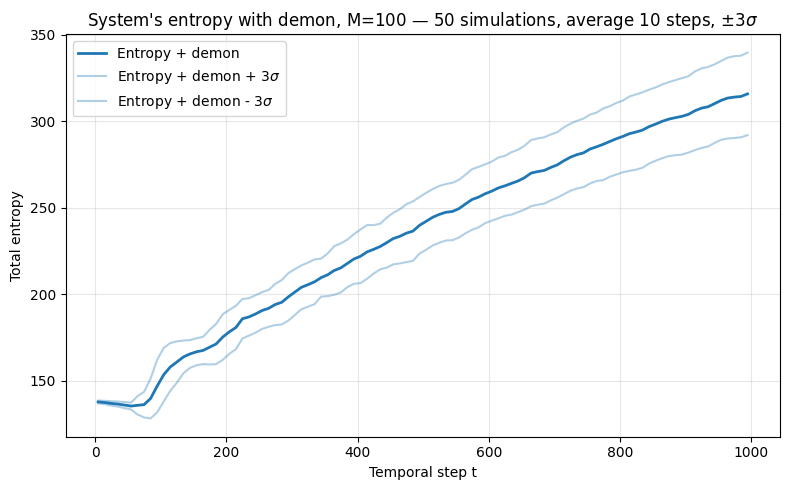

Plot guardado en: plots\evolucion_entropia_con_demonio_con_3_sigma_media_temporal.png


In [154]:
### ENTROPÍA + DEMONIO CON ERRORES #################
plot_evolucion_con_sigma_y_media_bloques(
    nombre_archivo_media="Ave_Demon_and_Entropy.txt",
    nombre_archivo_sigma="Sigma_Entropia_Demonio.txt",
    titulo=f"System's entropy with demon, M={memoria}",
    ylabel="Total entropy",
    nombre_guardado=f"evolucion_entropia_con_demonio_con_{num_sigmas}_sigma_media_temporal.png",
    etiquetas=["Entropy + demon"]
)

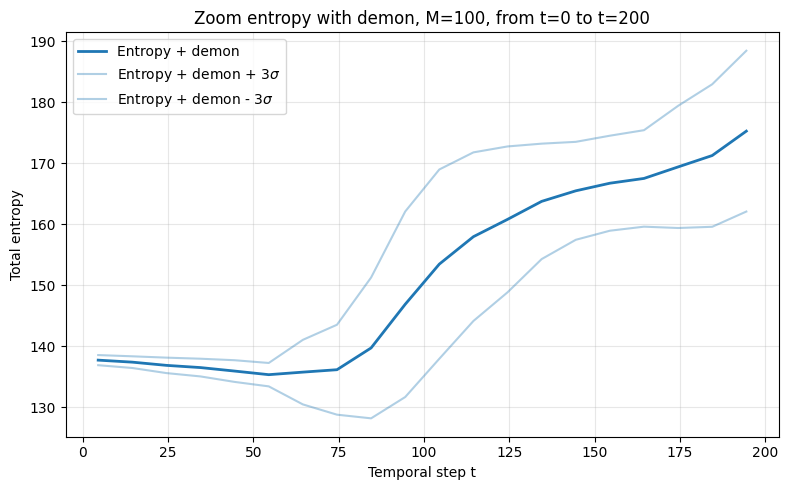

Plot guardado en: plots\zoom_entropia_con_demonio_M=100_A=0_B=200_con_3_sigma.png


In [155]:
### ZOOM ENTROPÍA + DEMONIO CON ERRORES #################

A = 0   # paso temporal inicial del zoom
B = 200   # paso temporal final del zoom


def plot_zoom_entropia_demonio(A, B):
    datos_media = leer_txt("Ave_Demon_and_Entropy.txt")
    datos_sigma = leer_txt("Sigma_Entropia_Demonio.txt")

    if datos_media.shape != datos_sigma.shape:
        raise ValueError(
            f"Las dimensiones no coinciden: {datos_media.shape} vs {datos_sigma.shape}"
        )

    # Media temporal cada 'media' pasos
    datos_media_bloques = media_temporal_por_bloques(datos_media, media)
    datos_sigma_bloques = sigma_temporal_por_bloques(datos_sigma, media)

    datos_error_bloques = num_sigmas * datos_sigma_bloques

    # Eje temporal real, usando el centro de cada bloque
    t = np.arange(datos_media_bloques.shape[0]) * media + (media - 1) / 2

    # Máscara para quedarnos solo entre A y B
    mascara = (t >= A) & (t <= B)

    if not np.any(mascara):
        raise ValueError(
            f"No hay puntos entre A={A} y B={B}. "
            f"Recuerda que estás promediando cada media={media} pasos."
        )

    t_zoom = t[mascara]
    y_zoom = datos_media_bloques[mascara, 0]
    error_zoom = datos_error_bloques[mascara, 0]

    plt.figure(figsize=(8, 5))

    linea, = plt.plot(
        t_zoom,
        y_zoom,
        linewidth=2,
        label="Entropy + demon"
    )

    color = linea.get_color()

    plt.plot(
        t_zoom,
        y_zoom + error_zoom,
        color=color,
        alpha=0.35,
        linewidth=1.5,
        label=f"Entropy + demon + {num_sigmas}$\\sigma$"
    )

    plt.plot(
        t_zoom,
        y_zoom - error_zoom,
        color=color,
        alpha=0.35,
        linewidth=1.5,
        label=f"Entropy + demon - {num_sigmas}$\\sigma$"
    )

    plt.xlabel("Temporal step t")
    plt.ylabel("Total entropy")
    plt.title(
        f"Zoom entropy with demon, M={memoria}, "
        f"from t={A} to t={B}"
    )

    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    nombre_guardado = (
        f"zoom_entropia_con_demonio_M={memoria}_"
        f"A={A}_B={B}_con_{num_sigmas}_sigma.png"
    )

    ruta_guardado = os.path.join(carpeta_plots, nombre_guardado)
    plt.savefig(ruta_guardado, dpi=300)
    plt.show()

    print(f"Plot guardado en: {ruta_guardado}")


plot_zoom_entropia_demonio(A, B)